# **Imports**

In [5]:
# modify sys root to import custom scripts...
import sys
import pathlib
project_root = pathlib.Path().resolve().parent
sys.path.append(str(project_root / "code"))

# import custom libraries...
from utils import *
from models.earthscape_dataset import *
from models.sgmapnet import *
from models.focal_loss import *
from models.training_utils import *

# additional libraries...
import os
import datetime
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.optim as optim


# **Parameters**

In [ ]:
############################################################
# Define parameters for training, validation, and testing
############################################################

# set seed for reproducibility....
seed = 111                                                               ##### USER DEFINED
set_seed(seed)


# dictionary of modality name & list of unique file extensions; optionally add addtional modalities (keys) & channels (values)
modality_configs = {                                                     ##### USER DEFINED
    'dem': {
        'channels': ['dem.tif']
        }, 
    'aerial': {
        'channels': ['aerialr.tif', 'aerialg.tif', 'aerialb.tif']
        }
    }


# get normalization parameters...
stats_path = r'../data/earthscape_image_stats.csv'                     ##### USER DEFINED
modality_configs = get_norm_stats(stats_path, modality_configs)


##### USER DEFINED
# list of directories containing patch data
patch_dirs = [r'../data/warren/patches_warren', 
              r'../data/howevalley/patches_howevalley', 
              r'../data/sonora/patches_sonora']


# get list of patch IDs & pytroch dataset...
# training set
train_patch_path = r'../splits/smoke_train.geojson'             ##### USER DEFINED
gdf = gpd.read_file(train_patch_path)
train_patch_ids = gdf['patch_id'].to_list()
train_dataset = EarthScape_Dataset(train_patch_ids, patch_dirs, modality_configs, augment=True)

# validation set
val_patch_path = r'../splits/smoke_val.geojson'                 ##### USER DEFINED
gdf = gpd.read_file(val_patch_path)
val_patch_ids = gdf['patch_id'].to_list()
val_dataset = EarthScape_Dataset(val_patch_ids, patch_dirs, modality_configs, augment=False)

# indomain test set
test_patch_path = r'../splits/smoke_test.geojson'               ##### USER DEFINED
gdf = gpd.read_file(test_patch_path)
test_patch_ids = gdf['patch_id'].to_list()
test_dataset = EarthScape_Dataset(test_patch_ids, patch_dirs, modality_configs, augment=False)

# cross domain test set
cross_test_patch_path = r'../splits/smoke_cross_test.geojson'   ##### USER DEFINED
gdf = gpd.read_file(cross_test_patch_path)
cross_test_patch_ids = gdf['patch_id'].to_list()
cross_test_dataset = EarthScape_Dataset(cross_test_patch_ids, patch_dirs, modality_configs, augment=False)


# model hyperparameters & settings...
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')     ##### USER DEFINED
batch_size = 4                                                            ##### USER DEFINED
num_epochs = 5                                                            ##### USER DEFINED
encoder = 'resnext'                                                           ##### USER DEFINED
model = SGMapNet_Classification(modality_configs, encoder, enable_attention=True, embedding_dim=512, num_heads=8, p_attn=0.0, p_resid=0.0).to(device)
optimizer = optim.Adam(model.parameters())


# dataloaders...
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
cross_test_loader = DataLoader(cross_test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)


# focal loss...
reduction = 'sum'                                                         ##### USER DEFINED
gamma = 2.0                                                               ##### USER DEFINED
alpha = 0.25                                                              ##### USER DEFINED
alpha = torch.tensor(alpha, dtype=torch.float32).view(1, -1).to(device)
criterion = FocalLoss(alpha=alpha, gamma=gamma, reduction=reduction).to(device)


# create output directory...
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
modality_str = '_'.join(list(modality_configs.keys()))
model_name = f"{encoder}_{modality_str}_{timestamp}"
output_dir = f"../models/smoke/{model_name}"                           ##### OPTIONAL: USER DEFINED
if not os.path.isdir(output_dir):
    os.makedirs(output_dir)
else:
    print('Directory already exists...')


# log metadata
training_log(model_name, output_dir, seed,
             train_patch_path, val_patch_path, test_patch_path, cross_test_patch_path,
             modality_configs, 
             batch_size, num_epochs, optimizer, criterion, model)

# **Dataloader Example**

In [7]:
# extract example
example = next(iter(val_loader))

# print data report
for modality in example.keys():
    print(modality)
    print(f"{type(example[modality])}  |  {example[modality].dtype}  |  {example[modality].shape}  |  {example[modality].min()}  |  {example[modality].max()}")

label
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([4, 7])  |  0.0  |  1.0
dem
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([4, 1, 256, 256])  |  -2.178584575653076  |  -0.0597664900124073
aerial
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([4, 3, 256, 256])  |  -2.595824718475342  |  7.101398468017578


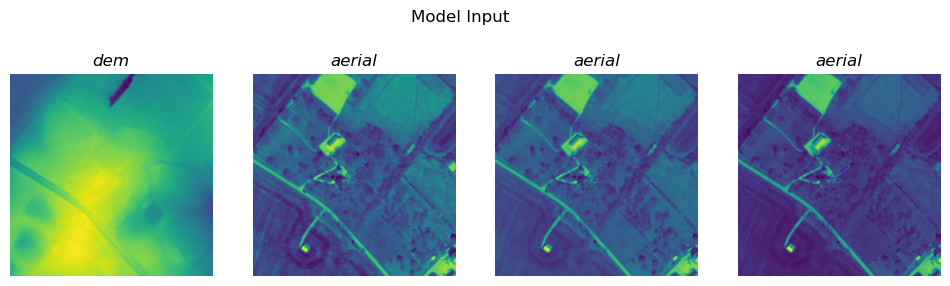

In [8]:

# extract total number of channels to plot...
num_channels = 0
for k,v in example.items():
    if not 'label' in k:
        num_channels += v.shape[1]

# define number of columns & rows...
ncols = min(4, num_channels)
nrows = (num_channels // ncols) + 1

# setup figure...
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 3*nrows))
ax = ax.ravel()

# plot channels separately...
idx = 0
for k,v in example.items():
    if 'label' in k:
        label = v.detach().numpy()[0]
        fig.suptitle(f"Model Input")
    else:
        v_sample = v.detach().numpy()[0]
        for c in range(v_sample.shape[0]):
            img = v_sample[c]
            min_val = img.min()
            max_val = img.max()
            img = (img - min_val) / (max_val - min_val + 1e-8)
            ax[idx].imshow(img)
            ax[idx].set_axis_off()
            ax[idx].set_title(k, style='italic')
            idx += 1

# remove any extra subplot axes...
for j in range(idx, len(ax)):
    fig.delaxes(ax[j])

plt.show()


# **Training**

In [9]:
df_train = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, output_dir)

Epoch 1
TRAINING   -- Loss: 1.2206  |  Accuracy: 66.07%  |  Time: 0.2 mins.
VALIDATION -- Loss: 1.0745  |  Accuracy: 72.62%  |  Time: 0.02 mins.
New best model saved!


Epoch 2
TRAINING   -- Loss: 1.0228  |  Accuracy: 69.64%  |  Time: 0.22 mins.
VALIDATION -- Loss: 1.1873  |  Accuracy: 58.33%  |  Time: 0.02 mins.


Epoch 3
TRAINING   -- Loss: 0.9176  |  Accuracy: 73.21%  |  Time: 0.22 mins.
VALIDATION -- Loss: 0.9350  |  Accuracy: 78.57%  |  Time: 0.02 mins.
New best model saved!


Epoch 4
TRAINING   -- Loss: 0.8363  |  Accuracy: 78.12%  |  Time: 0.23 mins.
VALIDATION -- Loss: 0.8849  |  Accuracy: 78.57%  |  Time: 0.02 mins.
New best model saved!


Epoch 5
TRAINING   -- Loss: 0.9101  |  Accuracy: 75.45%  |  Time: 0.22 mins.
VALIDATION -- Loss: 1.1813  |  Accuracy: 72.62%  |  Time: 0.02 mins.




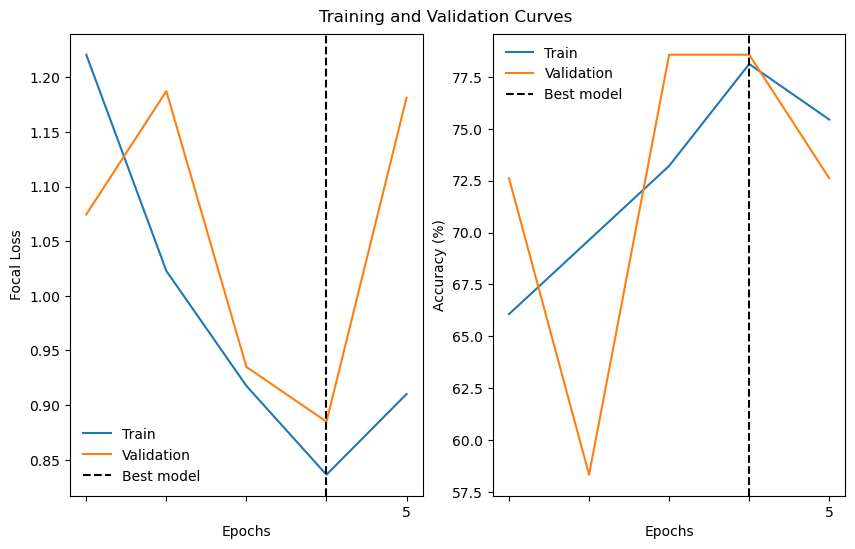

In [10]:
fig = plot_training_curves(df_train, output_dir)

fig.savefig(f"{output_dir}/training_curves.png", dpi=300, bbox_inches='tight', pad_inches=0)

# **Validation Set Tuning**

In [11]:
model_path = glob.glob(f"{output_dir}/best_loss_epoch*.pth")[0]

state_dict = torch.load(model_path, map_location=device, weights_only=False)

model.load_state_dict(state_dict)

optimal_thresholds = calculate_optimal_thresholds(model, val_loader, device)

# **In-Domain Inference**

## *Global Performance*

In [12]:

probabilities, targets = test_model(model, test_loader, device)

df_global = calculate_global_metrics(targets, probabilities, thresholds=optimal_thresholds)

df_global.to_csv(f"{output_dir}/indomain_global_metrics.csv", index=False)

df_global.head()

,Precision,Recall,F1,AUC,mAP,Precision (Wt.),Recall (Wt.),F1 (Wt.),AUC (Wt.),mAP (Wt.),Accuracy (Micro)
0,0.525837,0.734127,0.567449,0.764024,0.67488,0.732865,0.844444,0.766851,0.698175,0.790112,0.75


## *Per Class Performance*

In [13]:

df_class = calculate_class_metrics(targets, probabilities, thresholds=optimal_thresholds)

df_class.to_csv(f"{output_dir}/indomain_class_metrics.csv", index=False)

df_class.head(10)

/opt/miniconda3/envs/earthscape/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Class,True,Predicted,Accuracy,Precision,Recall,F1,AUC,AP
0,af1 (0.55),4.0,9.0,0.5625,0.333333,0.750000,0.461538,0.729167,0.684066
1,Qal (0.47),9.0,13.0,0.6250,0.615385,0.888889,0.727273,0.682540,0.741568
2,Qaf (0.3),1.0,7.0,0.6250,0.142857,1.000000,0.250000,0.933333,0.500000
3,Qat (0.35),1.0,0.0,0.9375,0.000000,0.000000,0.000000,0.800000,0.250000
4,Qc (0.41),8.0,7.0,0.8125,0.857143,0.750000,0.800000,0.906250,0.936298
5,Qca (0.42),8.0,7.0,0.8125,0.857143,0.750000,0.800000,0.796875,0.777816
6,Qr (0.6),14.0,16.0,0.8750,0.875000,1.000000,0.933333,0.500000,0.834412


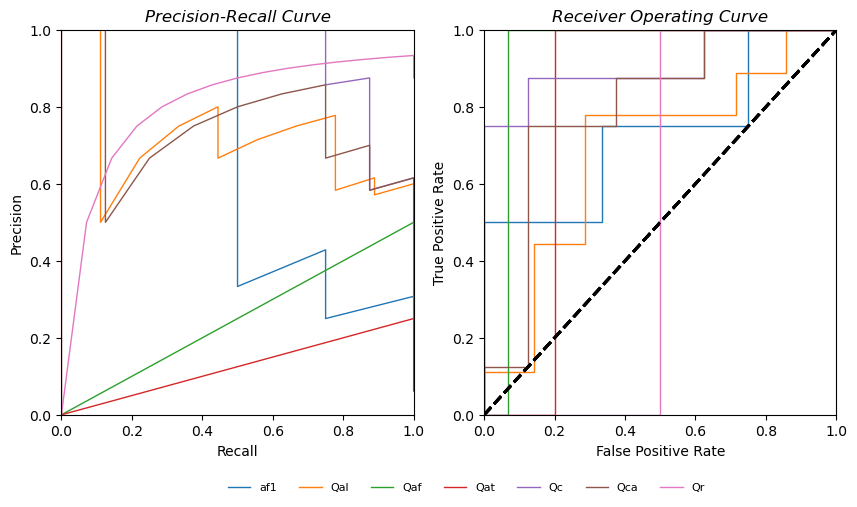

In [14]:

fig = plot_label_pr_roc_curves(targets, probabilities)

fig.savefig(f"{output_dir}/indomain_pr_curves.jpg")

# **Cross-Domain Inference**

## *Global Performance*

In [15]:
probabilities, targets = test_model(model, cross_test_loader, device)

df_cross_global = calculate_global_metrics(targets, probabilities, thresholds=optimal_thresholds)

df_cross_global.to_csv(f"{output_dir}/crossdomain_global_metrics.csv", index=False)

df_cross_global.head()

/opt/miniconda3/envs/earthscape/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/miniconda3/envs/earthscape/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,Precision,Recall,F1,AUC,mAP,Precision (Wt.),Recall (Wt.),F1 (Wt.),AUC (Wt.),mAP (Wt.),Accuracy (Micro)
0,0.383838,0.713203,0.466941,NaN,0.492405,0.652237,0.880952,0.721474,NaN,0.715869,0.535714


## *Per Class Performance*

In [16]:
df_cross_class = calculate_class_metrics(targets, probabilities, thresholds=optimal_thresholds)

df_cross_class.to_csv(f"{output_dir}/crossdomain_class_metrics.csv", index=False)

df_cross_class.head(10)

/opt/miniconda3/envs/earthscape/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,Class,True,Predicted,Accuracy,Precision,Recall,F1,AUC,AP
0,af1 (0.55),4.0,11.0,0.4375,0.272727,0.750000,0.400000,0.604167,0.373512
1,Qal (0.47),11.0,15.0,0.6250,0.666667,0.909091,0.769231,0.418182,0.658229
2,Qaf (0.3),1.0,11.0,0.2500,0.000000,0.000000,0.000000,0.266667,0.083333
3,Qat (0.35),3.0,9.0,0.3750,0.111111,0.333333,0.166667,0.205128,0.155093
4,Qc (0.41),5.0,11.0,0.6250,0.454545,1.000000,0.625000,0.872727,0.810000
5,Qca (0.42),2.0,11.0,0.4375,0.181818,1.000000,0.307692,0.821429,0.366667
6,Qr (0.6),16.0,16.0,1.0000,1.000000,1.000000,1.000000,NaN,1.000000


/opt/miniconda3/envs/earthscape/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


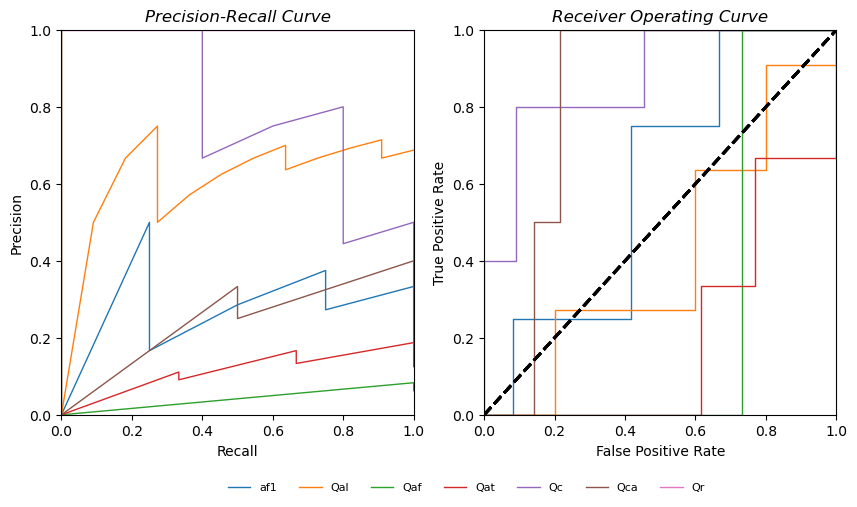

In [17]:

fig = plot_label_pr_roc_curves(targets, probabilities)

fig.savefig(f"{output_dir}/crossdomain_pr_curves.jpg")